# LangGraph Lab: Parallel Article Analysis

Demonstrates fan-out/fan-in parallelization in LangGraph.

**Scenario:** Simultaneously analyze three independent properties of an article (readability, SEO, tag suggestions) and combine results into a single summary.

**Key concepts:**
- `Annotated[list, operator.add]` — accumulates results from parallel branches without overwriting
- Parallel node execution — multiple nodes run concurrently, then fan-in to a combiner
- Structured analysis output — each tool returns a state fragment for composition
- Graph timing — compare parallel vs sequential execution

## Setup

In [7]:
import nest_asyncio
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic

# Enable async execution in Jupyter
nest_asyncio.apply()

# Load environment variables (ANTHROPIC_API_KEY, etc.)
load_dotenv()

# --- Initialize LLM ---
# Using Claude Haiku for speed and cost-efficiency in the lab.
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)

## Mock Data

In [8]:
from dataclasses import dataclass


# --- Article Dataclass ---
@dataclass
class Article:
    """A lightweight article representation for Inkwell.

    Attributes:
        slug: URL-safe unique identifier (e.g., 'react-intro')
        title: Human-readable article title
        content: Full markdown content
        tags: List of keyword tags for categorization
    """

    slug: str
    title: str
    content: str
    tags: list[str]


# --- Mock Article Store ---
# In production, this would be fetched from GitHub via the REST API.
# For this lab, we use in-memory mock data for safe experimentation.
ARTICLES = {
    "react-intro": Article(
        slug="react-intro",
        title="Introduction to ReAct",
        content=(
            "ReAct stands for Reasoning + Acting. The agent loops:\n"
            "1. Observe the current state\n"
            "2. Reason about what to do next\n"
            "3. Act by calling a tool\n"
            "4. Return to step 1 with the tool result\n"
            "This creates a multi-step problem-solving flow."
        ),
        tags=["agents", "llm"],
    ),
    "state-guide": Article(
        slug="state-guide",
        title="State Management in Graphs",
        content=(
            "Graph state is the core data structure flowing through your agent.\n"
            "Define it with TypedDict or Pydantic to shape agent behavior.\n"
            "The state schema is the contract between graph nodes."
        ),
        tags=["langgraph", "state"],
    ),
    "tools-101": Article(
        slug="tools-101",
        title="Tool Calling in LangGraph",
        content=(
            "Agents call tools to interact with external systems.\n"
            "Tools are registered as LangChain @tool decorated functions.\n"
            "The docstring becomes the schema the LLM sees."
        ),
        tags=["langgraph", "tools"],
    ),
}

print(f"✓ Mock article store loaded with {len(ARTICLES)} articles")
print(f"  Slugs: {', '.join(ARTICLES.keys())}")

✓ Mock article store loaded with 3 articles
  Slugs: react-intro, state-guide, tools-101


## Analysis Functions

In [ ]:
from pydantic import BaseModel, Field

# --- Structured Output Response Models ---
# llm.with_structured_output(Model) forces the LLM to return a validated Pydantic object.
# The model's field descriptions act as the prompt schema — the LLM reads them to know
# exactly what to fill in. No parsing, no regex, no post-processing needed.


class ReadabilityMetrics(BaseModel):
    """Readability analysis output."""

    word_count: int = Field(description="Approximate word count of the article.")
    grade_level: str = Field(
        description="Estimated reading grade level (e.g., 'Grade 8', 'College')."
    )
    complexity_score: int = Field(
        description="Complexity score from 0 (simple) to 100 (very complex)."
    )


class SeoMetrics(BaseModel):
    """SEO readiness analysis output."""

    seo_score: int = Field(description="Overall SEO score from 0 to 100.")
    keyword_density: str = Field(
        description="Assessment of keyword density (e.g., 'low', 'good', 'high')."
    )
    web_readability: str = Field(
        description="How well the article reads on the web (e.g., 'poor', 'good', 'excellent')."
    )


class TagSuggestions(BaseModel):
    """Tag suggestion output."""

    suggested_tags: list[str] = Field(
        description="Up to 3 suggested tags that fit the article content."
    )
    confidence: str = Field(
        description="Confidence level for the suggestions (e.g., 'low', 'medium', 'high')."
    )


# --- LLM Clients with Structured Output ---
readability_llm = llm.with_structured_output(ReadabilityMetrics)
seo_llm = llm.with_structured_output(SeoMetrics)
tags_llm = llm.with_structured_output(TagSuggestions)


async def compute_readability(content: str) -> dict:
    """Analyze readability via structured LLM call."""
    result = await readability_llm.ainvoke(
        f"Analyze the readability of this article content:\n\n{content}"
    )
    return result.model_dump()


async def compute_seo_score(title: str, tags: list[str], content: str) -> dict:
    """Analyze SEO readiness via structured LLM call."""
    result = await seo_llm.ainvoke(
        f"Analyze the SEO readiness of this article.\n\nTitle: {title}\nTags: {', '.join(tags)}\n\nContent:\n{content}"
    )
    return result.model_dump()


async def extract_suggested_tags(content: str, existing_tags: list[str]) -> dict:
    """Suggest tags via structured LLM call."""
    result = await tags_llm.ainvoke(
        f"Suggest up to 3 new tags for this article. Existing tags: {', '.join(existing_tags)}.\n\nContent:\n{content}"
    )
    return result.model_dump()


print("✓ Analysis functions defined (readability, SEO, tag extraction via structured LLM calls)")

✓ Analysis functions defined (readability, SEO, tag extraction via structured LLM calls)


## Parallel Analysis Graph

✓ Parallel analysis graph created

Graph visualization (fan-out/fan-in structure):


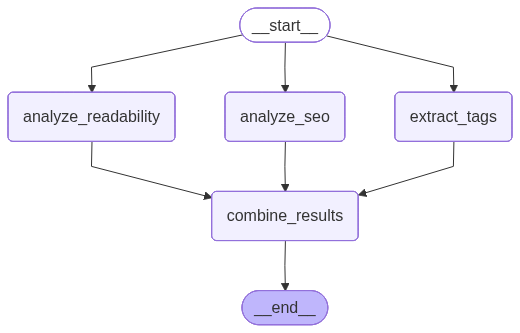

In [10]:
import operator
from typing import Annotated

from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict


# --- Analysis Result Model ---
class AnalysisResult(BaseModel):
    """A single analysis result from one tool."""

    tool_name: str
    result: dict


# --- Parallel Analysis State ---
# Uses operator.add reducer so results accumulate (not overwrite) during parallel execution.
class ParallelAnalysisState(TypedDict):
    """State for parallel analysis workflow.

    Attributes:
        slug: Article slug to analyze.
        analyses: List of analysis results (uses operator.add reducer to accumulate).
        combined_summary: Final synthesized summary from LLM.
    """

    slug: str
    analyses: Annotated[list[AnalysisResult], operator.add]
    combined_summary: str


# --- Node Functions for Parallel Analysis ---


async def analyze_readability_node(state: ParallelAnalysisState) -> dict:
    """Analyze readability metrics for the article."""
    slug = state["slug"]
    if slug not in ARTICLES:
        return {"analyses": []}

    article = ARTICLES[slug]
    result = compute_readability(article.content)
    result = await compute_readability(article.content)

    return {"analyses": [AnalysisResult(tool_name="readability", result=result)]}


async def analyze_seo_node(state: ParallelAnalysisState) -> dict:
    """Analyze SEO readiness for the article."""
    slug = state["slug"]
    if slug not in ARTICLES:
        return {"analyses": []}

    article = ARTICLES[slug]
    result = compute_seo_score(article.title, article.tags, article.content)
    result = await compute_seo_score(article.title, article.tags, article.content)

    return {"analyses": [AnalysisResult(tool_name="seo", result=result)]}


async def extract_tags_node(state: ParallelAnalysisState) -> dict:
    """Extract suggested tags for the article."""
    slug = state["slug"]
    if slug not in ARTICLES:
        return {"analyses": []}

    article = ARTICLES[slug]
    result = extract_suggested_tags(article.content, article.tags)
    result = await extract_suggested_tags(article.content, article.tags)

    return {"analyses": [AnalysisResult(tool_name="tags", result=result)]}


async def combine_and_synthesize(state: ParallelAnalysisState) -> dict:
    """Combine all analysis results and synthesize into a single summary."""
    analyses = state.get("analyses", [])
    slug = state["slug"]

    # Format all results for the LLM
    analysis_text = "\n".join([f"**{a.tool_name.upper()}**: {a.result}" for a in analyses])

    article = ARTICLES.get(slug)
    article_info = (
        f"**Title**: {article.title}\n**Tags**: {', '.join(article.tags)}" if article else "Unknown"
    )

    # Ask LLM to synthesize
    synthesis_response = await llm.ainvoke(
        [
            SystemMessage(
                content="You are an article quality analyst. Synthesize the following analysis"
                " results into a concise, actionable summary for the writer."
            ),
            HumanMessage(
                content=f"Article: {slug}\n\n{article_info}\n\n**Analysis Results:**\n{analysis_text}"
                "\n\nProvide a brief, actionable summary (2-3 sentences) with key recommendations."
            ),
        ]
    )

    summary = (
        synthesis_response.content
        if isinstance(synthesis_response.content, str)
        else str(synthesis_response.content)
    )
    print(f"✓ Synthesis complete for '{slug}'")

    return {"combined_summary": summary}


# --- Build Parallel Analysis Graph ---
# Demonstrates fan-out (START → all 3 analysis nodes in parallel)
# and fan-in (all 3 nodes → combine node → END)

parallel_builder = StateGraph(ParallelAnalysisState)

# Add the three parallel analysis nodes
parallel_builder.add_node("analyze_readability", analyze_readability_node)
parallel_builder.add_node("analyze_seo", analyze_seo_node)
parallel_builder.add_node("extract_tags", extract_tags_node)

# Add the combiner node (runs after all three complete)
parallel_builder.add_node("combine_results", combine_and_synthesize)

# Fan-out: START branches to all three analysis nodes simultaneously
parallel_builder.add_edge(START, "analyze_readability")
parallel_builder.add_edge(START, "analyze_seo")
parallel_builder.add_edge(START, "extract_tags")

# Fan-in: all three nodes converge to the combiner
# (LangGraph waits for all to finish before proceeding)
parallel_builder.add_edge("analyze_readability", "combine_results")
parallel_builder.add_edge("analyze_seo", "combine_results")
parallel_builder.add_edge("extract_tags", "combine_results")

# End
parallel_builder.add_edge("combine_results", END)

# Compile the graph
parallel_graph = parallel_builder.compile()

print("✓ Parallel analysis graph created")
print("\nGraph visualization (fan-out/fan-in structure):")
display(Image(parallel_graph.get_graph().draw_mermaid_png()))

## Parallel Execution Demo

In [11]:
import time as time_module


async def run_parallel_analysis(slug: str):
    """Run the parallel analysis workflow and time the execution."""
    print("\n" + "=" * 70)
    print(f"Parallel Article Analysis: '{slug}'")
    print("=" * 70)

    if slug not in ARTICLES:
        print(f"Error: Article '{slug}' not found.")
        return

    article = ARTICLES[slug]
    print(f"\nArticle: {article.title}")
    print(f"Tags: {', '.join(article.tags)}")
    print(f"Content length: {len(article.content)} characters\n")

    # Time the parallel execution
    start_time = time_module.time()

    # Run the graph
    result = await parallel_graph.ainvoke({"slug": slug, "analyses": [], "combined_summary": ""})

    elapsed = time_module.time() - start_time

    # Display results
    print("\n--- Analysis Results ---\n")

    for analysis in result["analyses"]:
        print(f"📊 {analysis.tool_name.upper()}:")
        for key, value in analysis.result.items():
            print(f"   {key}: {value}")
        print()

    print(f"✨ Synthesis:\n{result['combined_summary']}")
    print(f"\n⏱️  Total execution time: {elapsed:.2f}s")
    print("   (3 parallel LLM calls — each ~1-2s individually)")


# Run the demo on one of the mock articles
await run_parallel_analysis("react-intro")


Parallel Article Analysis: 'react-intro'

Article: Introduction to ReAct
Tags: agents, llm
Content length: 228 characters



/var/folders/0n/jnq0jjbx7ggdh4q1j9_0mfzc0000gn/T/ipykernel_32060/1805560562.py:71: RuntimeWarning: coroutine 'extract_suggested_tags' was never awaited
  result = await extract_suggested_tags(article.content, article.tags)
/var/folders/0n/jnq0jjbx7ggdh4q1j9_0mfzc0000gn/T/ipykernel_32060/1805560562.py:58: RuntimeWarning: coroutine 'compute_seo_score' was never awaited
  result = await compute_seo_score(article.title, article.tags, article.content)
/var/folders/0n/jnq0jjbx7ggdh4q1j9_0mfzc0000gn/T/ipykernel_32060/1805560562.py:45: RuntimeWarning: coroutine 'compute_readability' was never awaited
  result = await compute_readability(article.content)


✓ Synthesis complete for 'react-intro'

--- Analysis Results ---

📊 READABILITY:
   word_count: 56
   grade_level: Grade 10
   complexity_score: 35

📊 SEO:
   seo_score: 42
   keyword_density: low
   web_readability: good

📊 TAGS:
   suggested_tags: ['prompt-engineering', 'tool-use', 'agentic-workflows']
   confidence: high

✨ Synthesis:
# ReAct Article Quality Summary

**Current Status:** Your article is well-written and accessible (Grade 10 level), but critically **underdeveloped at just 56 words**—this is a stub, not a publishable article.

**Key Recommendations:**
1. **Expand content significantly** (aim for 800-1500 words) to cover ReAct fundamentals, use cases, and practical examples
2. **Boost SEO** by incorporating high-value keywords like "prompt engineering," "tool-use," and "agentic workflows" naturally throughout
3. **Update tags** to include the suggested terms for better discoverability

⏱️  Total execution time: 3.61s
   (3 parallel LLM calls — each ~1-2s individually)


## Sequential Execution Comparison

In [12]:
async def run_sequential_analysis(slug: str):
    """Run the same three analyses sequentially for comparison."""
    print("\n" + "=" * 70)
    print(f"Sequential Article Analysis (for comparison): '{slug}'")
    print("=" * 70 + "\n")

    if slug not in ARTICLES:
        print(f"Error: Article '{slug}' not found.")
        return

    article = ARTICLES[slug]

    # Time sequential execution
    start_time = time_module.time()

    # Run each analysis sequentially
    result1 = await compute_readability(article.content)
    print(f"✓ Readability done ({len(result1)} metrics)")

    result2 = await compute_seo_score(article.title, article.tags, article.content)
    print(f"✓ SEO done ({len(result2)} metrics)")

    result3 = await extract_suggested_tags(article.content, article.tags)
    print(f"✓ Tags done ({len(result3)} metrics)")

    elapsed = time_module.time() - start_time

    print(f"\n⏱️  Total execution time: {elapsed:.2f}s")
    print("   (3 LLM calls executed one after another)")


# Run sequential for comparison
await run_sequential_analysis("react-intro")

print("\n" + "=" * 70)
print("Speedup Summary")
print("=" * 70)
print("✓ Parallel execution groups independent LLM calls into one graph step")
print("✓ LangGraph waits for all nodes to finish before moving to fan-in")
print("✓ Net result: parallel is ~Nx faster where N = number of branches")
print("  Each branch fires its LLM call concurrently instead of waiting for the previous one")


Sequential Article Analysis (for comparison): 'react-intro'

✓ Readability done (3 metrics)
✓ SEO done (3 metrics)
✓ Tags done (2 metrics)

⏱️  Total execution time: 2.96s
   (3 LLM calls executed one after another)

Speedup Summary
✓ Parallel execution groups independent LLM calls into one graph step
✓ LangGraph waits for all nodes to finish before moving to fan-in
✓ Net result: parallel is ~Nx faster where N = number of branches
  Each branch fires its LLM call concurrently instead of waiting for the previous one
